# Projeto Final

A odometria é uma técnica amplamente utilizada para estimar, de forma aproximada, a posição e a orientação de um robô móvel ao longo do tempo, com base na medição do deslocamento de suas rodas.

Um dos sensores mais comuns usados para esse fim é o encoder incremental, um dispositivo que conta os giros (ou incrementos de rotação) de cada roda, permitindo calcular a distância percorrida.

A ideia por trás do processo de odometria envolve a integração numérica do movimento do robô ao longo do tempo. É evidente que qualquer erro proveniente dos sensores — como imprecisões na leitura da direção ou distância percorrida — interfere diretamente na determinação da posição. Isso ocorre porque esses erros tendem a se acumular ao longo do tempo, à medida que o robô percorre o caminho em busca de seu destino.

Esse método é bastante viável quando o destino está relativamente próximo do ponto de partida, pois é simples de implementar e fornece uma boa aproximação da posição.

A odometria é normalmente realizada com base nos dados dos encoders localizados nas rodas do robô, assumindo que as revoluções das rodas correspondem a deslocamentos lineares em relação ao solo.

Considere um robô diferencial com duas rodas, cada uma equipada com um encoder incremental. A distância entre as rodas (eixo) $d$ é de $0,4 m$, e o raio de cada roda (direita $r_R$ e esquerda $r_L$) é $0,1 m$, ou seja, $r = r_R = r_L$. 

Assuma que o robô parte da posição inicial ($x_0$, $y_0$) = ($0$, $0$) com orientação $\psi_{0} = 0\ rad$.

<img src="img-robo.png" alt="image" size="100%" position="center">

Para robôs móveis com tração diferencial, como o robô uniciclo da figura, as velocidades das rodas podem ser usadas para calcular as velocidades linear e angular do robô em relação ao solo. Que são sinais de controle de alto nível para o robô. Dadas a velocidade angular da roda direita $\omega_R$ e da roda esquerda $\omega_L$, expressa em $rad/s$,  as equações para determinar a velocidade do robô são:

Velocidade linear: $u = r \frac{\omega_R + \omega_L}{2}$
Velocidade angular: $\omega = r \frac{\omega_R - \omega_L}{d}$

Com essas equações, é possível estimar o movimento do robô a partir dos dados de velocidade medidos por encoders instalados nas rodas.

O modelo cinemático de um robô do tipo uniciclo com deslocamento do ponto de controle $h$ é dado por:

$$
\left[
    \begin{array}{c}
    \dot{x} \\
    \dot{y} \\
    \dot{\psi}
    \end{array}
\right]=
\left[
    \begin{array}{cc}
    \cos\psi & -a \sin\psi \\
    \sin\psi & a\cos\psi \\
    0 & 1
    \end{array}
\right]
\left[
    \begin{array}{c}
    u \\
    \omega
    \end{array}
\right]
$$

Onde:

- $(x, y)$: representa a posição do robô no plano cartesiano.
- $\psi$: é o ângulo de orientação do robô em relação ao eixo $x$.
- $u$: é a velocidade linear e $\omega$ é a velocidade angular aplicada ao robô.
- $a$: é a distância entre o eixo virtual que une as rodas do robô e o ponto de aplicação do controle.

Em função dos dados de velocidade das rodas direta e esquerda do robô, determine a rota navegada, sabendo que $a = 0,10$ m.


Para tal, realize os seguintes passos:

1. Realize a leitura do arquivo de dados `RwL.txt`, o qual possui 400 linhas e 3 colunas. Em outras palavras, o arquivo contém 400 medidas de tempo, velocidade da roda direita $\omega_{R}$ e velocidade da roda esquerda $\omega_{L}$.

2. Para demonstrar a evolução temporal das velocidades das rodas, plote os gráficos que relaciona o $tempo \times \omega_{R}$ e o $tempo \times \omega_{L}$.

3. Transforme as velocidades $\omega_{R}$ e $\omega_{L}$ em sinais de controle $u$ e $\omega$

4. Para demonstrar a evolução temporal dos sinais de controle do robô, plote os gráficos que relaciona o $tempo \times u$ e o $tempo \times \omega$.

5. Use o modelo cinemático, para determinar a posição e orientação do robô ao longo do tempo. A título de exemplo, para determinar a orientação do robô, faça $\psi(k) = \frac{\psi(k) - \psi(k-1)}{\Delta t} = \omega$, ou ainda $\psi(k) = \psi(k-1) + \omega \Delta t$.

6. Para demonstrar a evolução temporal da posição e orientação do robô, plote os gráficos que relaciona o $tempo \times x$ e o $tempo \times y$, o &tempo \times \psi$

7. Para demonstrar a navegação do robô no plano cartesiano, plote o gráfico que relaciona $x$ e $y$.

8. Informe numericamente a posição final do robô ao final do experimento.


In [1]:
# !pip install matplotlib
# !pip install numpy

## 1

Realize a leitura do arquivo de dados `RwL.txt`, o qual possui 400 linhas e 3 colunas. Em outras palavras, o arquivo contém 400 medidas de tempo, velocidade da roda direita $\omega_{R}$ e velocidade da roda esquerda $\omega_{L}$.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("wRwL.txt", sep=r"\s+", header=None, names=["t", "omega_R", "omega_L"])
print(df.head())

print(df.describe())

df.info()

        t  omega_R  omega_L
0  0.0130   8.3775  -2.2848
1  0.1301   7.0683   0.0915
2  0.2106   5.9269   1.5972
3  0.3106   5.1135   2.4625
4  0.4145   4.5689   2.9364
                t     omega_R     omega_L
count  400.000000  400.000000  400.000000
mean    19.961254    0.837067    1.237123
std     11.561648    1.747158    1.501812
min      0.013000   -8.630300   -2.284800
25%      9.985475    0.106475    0.133600
50%     19.963150    0.557900    0.642750
75%     29.935900    1.707350    1.949300
max     39.912100    8.377500    8.295000
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   t        400 non-null    float64
 1   omega_R  400 non-null    float64
 2   omega_L  400 non-null    float64
dtypes: float64(3)
memory usage: 9.5 KB


## 2

Para demonstrar a evolução temporal das velocidades das rodas, plote os gráficos que relaciona o $tempo \times \omega_{R}$ e o $tempo \times \omega_{L}$.

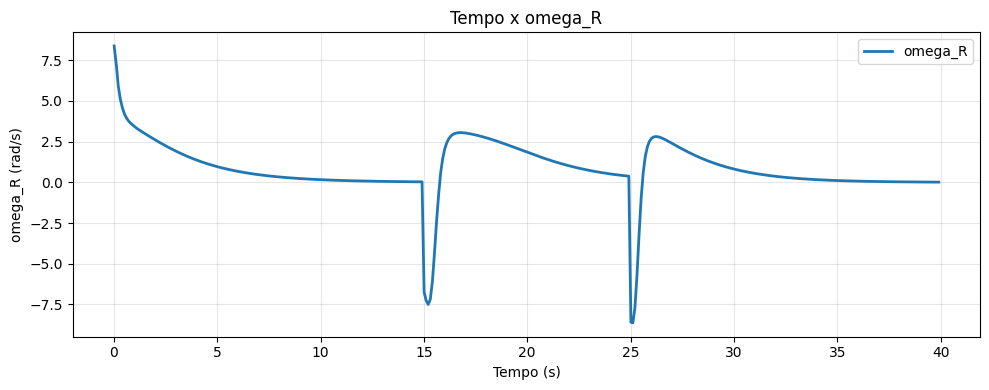

In [3]:
#------------------------------------------------------------
#                     tempo x omega_R
# ------------------------------------------------------------

plt.figure(figsize=(10, 4))
plt.plot(
    df["t"],
    df["omega_R"],
    color="tab:blue",
    linewidth=2,
    label="omega_R"
)
plt.xlabel("Tempo (s)")
plt.ylabel("omega_R (rad/s)")
plt.title("Tempo x omega_R")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("tempo_x_omega_R.png", dpi=200, bbox_inches="tight")

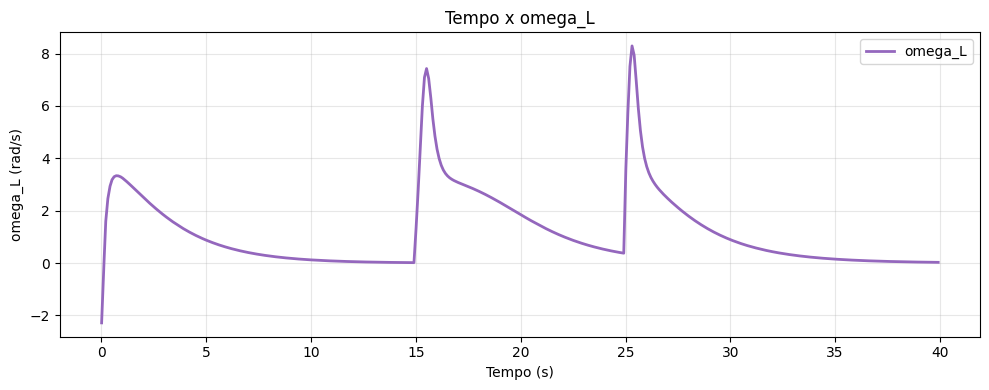

In [4]:
# ------------------------------------------------------------
#                   tempo x omega_L
# ------------------------------------------------------------

plt.figure(figsize=(10, 4))
plt.plot(
    df["t"],
    df["omega_L"],
    color="tab:purple",
    linewidth=2,
    label="omega_L"
)
plt.xlabel("Tempo (s)")
plt.ylabel("omega_L (rad/s)")
plt.title("Tempo x omega_L")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("tempo_x_omega_L.png", dpi=200, bbox_inches="tight")

In [5]:
# salvar os dados lidos em CSV

df.to_csv("dados.csv", index=False)

## 3

In [6]:
# ------------------------------------------------------------
#       Definir parâmetros físicos do robô
# ------------------------------------------------------------
r = 0.1   # raio da roda em metros
d = 0.4   # distância entre as rodas em metros

# ------------------------------------------------------------
# 3) Converter velocidades das rodas em sinais de controle
# ------------------------------------------------------------
# u é a velocidade linear do robô.
# Ela é a média das velocidades lineares das rodas.
df["u"] = r * (df["omega_R"] + df["omega_L"]) / 2

# omega é a velocidade angular do robô.
# Ela depende da diferença entre as rodas.
df["omega"] = r * (df["omega_R"] - df["omega_L"]) / d

# ------------------------------------------------------------
#             Exibir os resultados
# ------------------------------------------------------------
print("Primeiras linhas com os sinais de controle calculados:")
print(df.head())
print()

print("Estatísticas dos sinais de controle:")
print(df[["u", "omega"]].describe())
print()

print("Valores extremos:")
print(f"u mínimo   = {df['u'].min():.4f} m/s")
print(f"u máximo   = {df['u'].max():.4f} m/s")
print(f"omega mín  = {df['omega'].min():.4f} rad/s")
print(f"omega máx  = {df['omega'].max():.4f} rad/s")

# salvar o resultado em CSV
df.to_csv("sinais_controle_u_omega.csv", index=False)

Primeiras linhas com os sinais de controle calculados:
        t  omega_R  omega_L         u     omega
0  0.0130   8.3775  -2.2848  0.304635  2.665575
1  0.1301   7.0683   0.0915  0.357990  1.744200
2  0.2106   5.9269   1.5972  0.376205  1.082425
3  0.3106   5.1135   2.4625  0.378800  0.662750
4  0.4145   4.5689   2.9364  0.375265  0.408125

Estatísticas dos sinais de controle:
                u       omega
count  400.000000  400.000000
mean     0.103710   -0.100014
std      0.114960    0.577153
min     -0.270265   -3.801325
25%      0.012151   -0.014025
50%      0.060123   -0.000125
75%      0.184851    0.010450
max      0.378800    2.665575

Valores extremos:
u mínimo   = -0.2703 m/s
u máximo   = 0.3788 m/s
omega mín  = -3.8013 rad/s
omega máx  = 2.6656 rad/s


## 4

Para demonstrar a evolução temporal dos sinais de controle do robô, plote os gráficos que relaciona o $tempo \times u$ e o $tempo \times \omega$

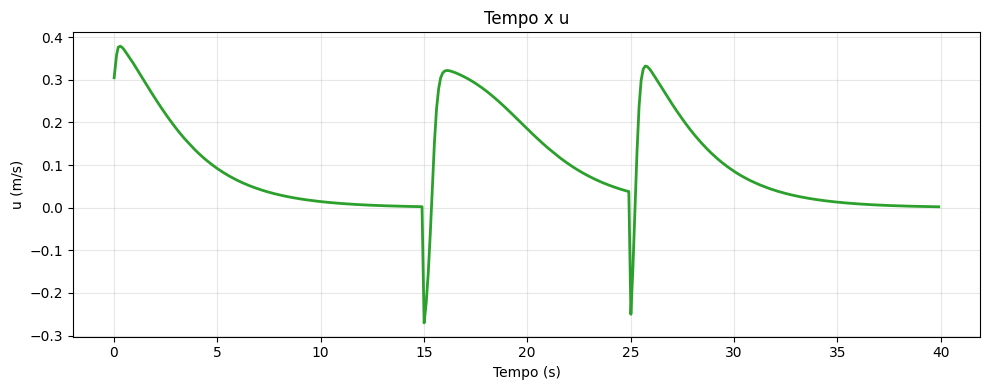

In [7]:
df = pd.read_csv("sinais_controle_u_omega.csv")

# ------------------------------------------------------------
#                     tempo x u
# ------------------------------------------------------------
plt.figure(figsize=(10, 4))
plt.plot(df["t"], df["u"], color="tab:green", linewidth=2)
plt.xlabel("Tempo (s)")
plt.ylabel("u (m/s)")
plt.title("Tempo x u")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("tempo_x_u.png", dpi=200, bbox_inches="tight")

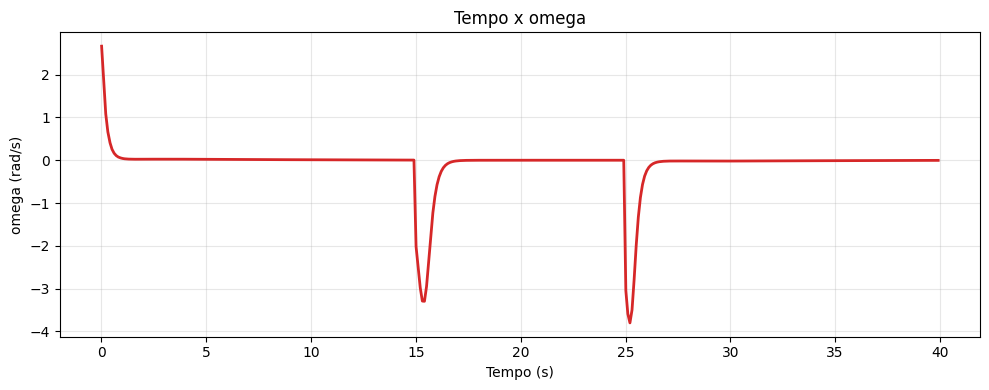

In [8]:
# ------------------------------------------------------------
#                     tempo x omega
# ------------------------------------------------------------
plt.figure(figsize=(10, 4))
plt.plot(df["t"], df["omega"], color="tab:red", linewidth=2)
plt.xlabel("Tempo (s)")
plt.ylabel("omega (rad/s)")
plt.title("Tempo x omega")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("tempo_x_omega.png", dpi=200, bbox_inches="tight")

## 5

Use o modelo cinemático, para determinar a posição e orientação do robô ao longo do tempo. A título de exemplo, para determinar a orientação do robô, faça $$\psi(k) = \frac{\psi(k) - \psi(k-1)}{\Delta t} = \omega$$, ou ainda $$\psi(k) = \psi(k-1) + \omega \Delta t$$.

In [9]:
df = pd.read_csv("sinais_controle_u_omega.csv")

# ------------------------------------------------------------
#                     Parâmetros do robô
# ------------------------------------------------------------

a = 0.10   # distância entre o ponto de controle e o eixo das rodas

# ------------------------------------------------------------
#                 Inicializar as variáveis de estado
# ------------------------------------------------------------
# O robô começa na origem com orientação zero.
x = np.zeros(len(df))
y = np.zeros(len(df))
psi = np.zeros(len(df))

x[0] = 0.0
y[0] = 0.0
psi[0] = 0.0

# ------------------------------------------------------------
#          Integrar o modelo cinemático no tempo
# ------------------------------------------------------------
# usando o método de Euler, que atualiza o estado passo-a-passo
for k in range(1, len(df)):
    # Intervalo de tempo entre amostras consecutivas
    dt = df["t"].iloc[k] - df["t"].iloc[k - 1]

    # Valores do instante anterior
    u_k = df["u"].iloc[k - 1]
    omega_k = df["omega"].iloc[k - 1]
    psi_k = psi[k - 1]

    # Derivadas do modelo cinemático
    x_dot = u_k * np.cos(psi_k) - a * omega_k * np.sin(psi_k)
    y_dot = u_k * np.sin(psi_k) + a * omega_k * np.cos(psi_k)

    # Atualização do estado
    x[k] = x[k - 1] + x_dot * dt
    y[k] = y[k - 1] + y_dot * dt
    psi[k] = psi[k - 1] + omega_k * dt

# ------------------------------------------------------------
#         Armazenar os resultados no DataFrame
# ------------------------------------------------------------
df["x"] = x
df["y"] = y
df["psi"] = psi

# ------------------------------------------------------------
#                   Exibir resultados
# ------------------------------------------------------------
print("Primeiras linhas com posição e orientação calculadas:")
print(df[["t", "u", "omega", "x", "y", "psi"]].head())
print()

print("Últimas linhas:")
print(df[["t", "u", "omega", "x", "y", "psi"]].tail())
print()

print("Resumo final:")
print(f"Posição final: ({x[-1]:.4f}, {y[-1]:.4f}) m")
print(f"Orientação final: {psi[-1]:.4f} rad")
print(f"Orientação final: {np.degrees(psi[-1]):.2f} graus")


df.to_csv("odometria_posicao_orientacao.csv", index=False)

Primeiras linhas com posição e orientação calculadas:
        t         u     omega         x         y       psi
0  0.0130  0.304635  2.665575  0.000000  0.000000  0.000000
1  0.1301  0.357990  1.744200  0.035673  0.031214  0.312139
2  0.2106  0.376205  1.082425  0.058787  0.053426  0.452547
3  0.3106  0.378800  0.662750  0.087887  0.079611  0.560789
4  0.4145  0.375265  0.408125  0.117554  0.106374  0.629649

Últimas linhas:
           t         u     omega         x         y       psi
395  39.5116  0.002385 -0.003775 -0.010481 -0.016580 -3.976571
396  39.6114  0.002300 -0.003700 -0.010613 -0.016378 -3.976948
397  39.7117  0.002210 -0.003600 -0.010740 -0.016182 -3.977319
398  39.8116  0.002130 -0.003500 -0.010862 -0.015994 -3.977679
399  39.9121  0.002055 -0.003425 -0.010979 -0.015812 -3.978031

Resumo final:
Posição final: (-0.0110, -0.0158) m
Orientação final: -3.9780 rad
Orientação final: -227.92 graus


## 6

Para demonstrar a evolução temporal da posição e orientação do robô, plote os gráficos que relaciona o $tempo \times x$ e o $tempo \times y$, o  $tempo \times \psi$

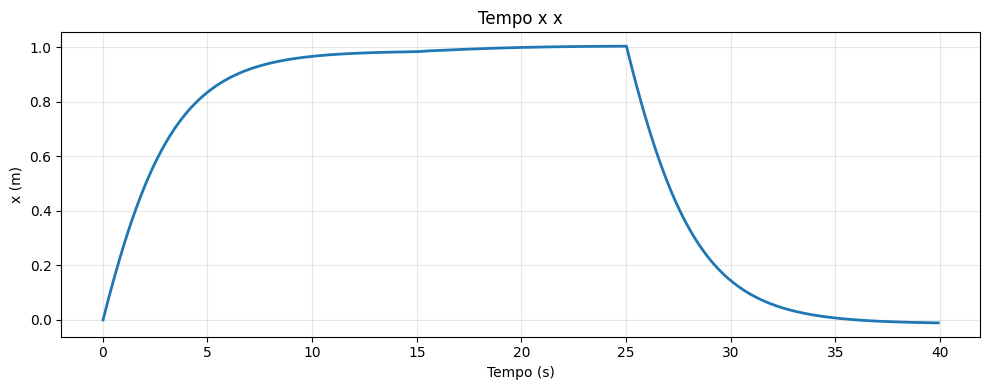

In [10]:
df = pd.read_csv("odometria_posicao_orientacao.csv")

# ------------------------------------------------------------
#                     tempo x x
# ------------------------------------------------------------
plt.figure(figsize=(10, 4))
plt.plot(df["t"], df["x"], color="tab:blue", linewidth=2)
plt.xlabel("Tempo (s)")
plt.ylabel("x (m)")
plt.title("Tempo x x")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("tempo_x_x.png", dpi=150, bbox_inches="tight")

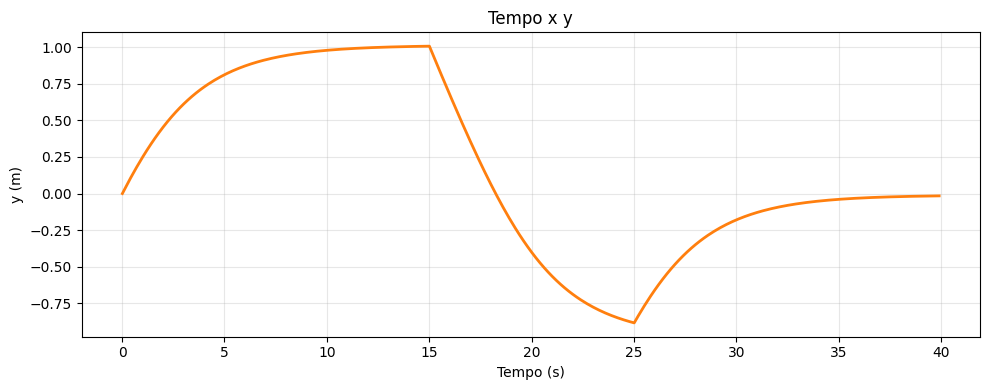

In [11]:
# ------------------------------------------------------------
#                     tempo x y
# ------------------------------------------------------------
plt.figure(figsize=(10, 4))
plt.plot(df["t"], df["y"], color="tab:orange", linewidth=2)
plt.xlabel("Tempo (s)")
plt.ylabel("y (m)")
plt.title("Tempo x y")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("tempo_x_y.png", dpi=150, bbox_inches="tight")

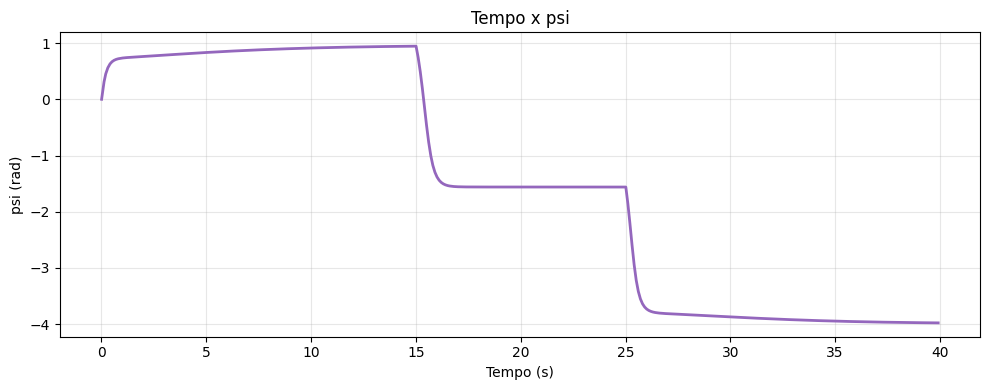

In [12]:
# ------------------------------------------------------------
#                     tempo x psi
# ------------------------------------------------------------
plt.figure(figsize=(10, 4))
plt.plot(df["t"], df["psi"], color="tab:purple", linewidth=2)
plt.xlabel("Tempo (s)")
plt.ylabel("psi (rad)")
plt.title("Tempo x psi")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("tempo_x_psi.png", dpi=150, bbox_inches="tight")

## 7

Para demonstrar a navegação do robô no plano cartesiano, plote o gráfico que relaciona x e y.

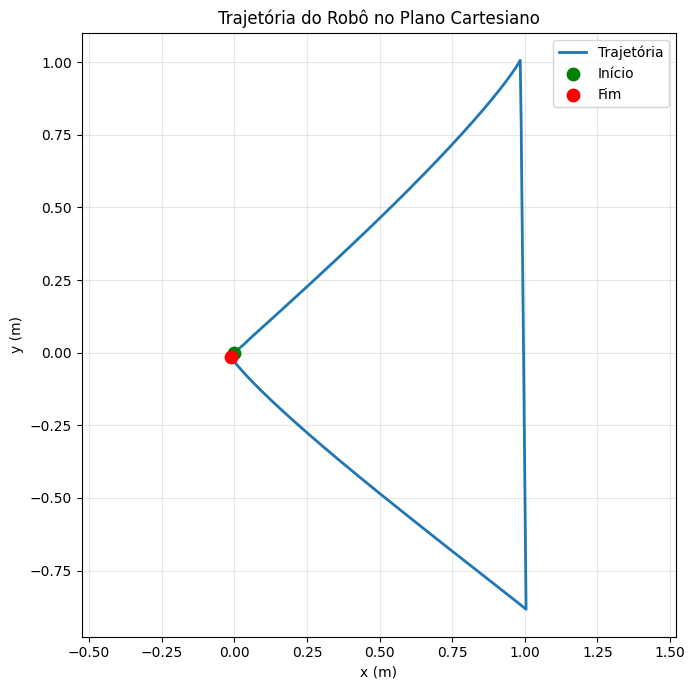

In [13]:
df = pd.read_csv("odometria_posicao_orientacao.csv")

# ------------------------------------------------------------
#                     Gráfico da trajetória x vs y
# ------------------------------------------------------------
plt.figure(figsize=(7, 7))
plt.plot(df["x"], df["y"], color="tab:blue", linewidth=2, label="Trajetória")

# Marcar o ponto inicial e final para facilitar a leitura
plt.scatter(df["x"].iloc[0], df["y"].iloc[0], color="green", s=80, label="Início", zorder=5)
plt.scatter(df["x"].iloc[-1], df["y"].iloc[-1], color="red", s=80, label="Fim", zorder=5)

plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Trajetória do Robô no Plano Cartesiano")
plt.grid(True, alpha=0.3)
plt.axis("equal")
plt.legend()
plt.tight_layout()
plt.savefig("trajetoria_xy.png", dpi=200, bbox_inches="tight")

## 8

Informe numericamente a posição final do robô ao final do experimento.

In [14]:
df = pd.read_csv("sinais_controle_u_omega.csv")

# Parâmetro geométrico do robô
a = 0.10   # distância entre o ponto de controle e o eixo das rodas

# Inicializar os vetores de estado
# x, y e psi começam em zero na origem
x = np.zeros(len(df))
y = np.zeros(len(df))
psi = np.zeros(len(df))

# Condições iniciais
x[0] = 0.0
y[0] = 0.0
psi[0] = 0.0

# Integração numérica pelo método de Euler
# Para cada instante, calculo das derivadas e atualização do estado
for k in range(1, len(df)):
    # Intervalo de tempo entre amostras
    dt = df["t"].iloc[k] - df["t"].iloc[k - 1]

    # Valores do instante anterior
    u_k = df["u"].iloc[k - 1]
    omega_k = df["omega"].iloc[k - 1]
    psi_k = psi[k - 1]

    # Equações cinemáticas do robô diferencial
    x_dot = u_k * np.cos(psi_k) - a * omega_k * np.sin(psi_k)
    y_dot = u_k * np.sin(psi_k) + a * omega_k * np.cos(psi_k)

    # Atualização de posição e orientação
    x[k] = x[k - 1] + x_dot * dt
    y[k] = y[k - 1] + y_dot * dt
    psi[k] = psi[k - 1] + omega_k * dt

# Mostrar o resultado final
print(f"Posição final: ({x[-1]:.6f}, {y[-1]:.6f}) m")
print(f"Orientação final: {psi[-1]:.6f} rad")
print(f"Orientação final: {np.degrees(psi[-1]):.2f} graus")

# Salvar os resultados em CSV
out = df.copy()
out["x"] = x
out["y"] = y
out["psi"] = psi
out.to_csv("odometria_posicao_orientacao.csv", index=False)

Posição final: (-0.010979, -0.015812) m
Orientação final: -3.978031 rad
Orientação final: -227.92 graus
